In [1]:
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
import math
import time
from datetime import datetime
from IPython.display import HTML
from utilities_func import *   
from torch.utils.data import DataLoader, TensorDataset

In [2]:
from Genetic_utils import *

In [3]:
class MLP_sigmoid(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, pars_W):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.activation = torch.sigmoid
        self.fc2 = nn.Linear(hidden_size, output_size)
        
        if pars_W is not None:
            self.set_weights(pars_W)
        else:
            self.init_weights()
        
        global dict
        if dict['seed'] is not None:
            torch.manual_seed(dict['seed'])
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x      
    
    def init_weights(self):
        init.xavier_uniform_(self.fc1.weight)
        init.zeros_(self.fc1.bias)
        init.xavier_uniform_(self.fc2.weight)
        init.zeros_(self.fc2.bias)
    
    def set_weights(self, pars_W):
        with torch.no_grad():
            for param, p in zip(self.parameters(), pars_W):
                param.copy_(torch.tensor(p))
    
    def train_network(self, lr, epochs, X, Y,patience=10,early_stopping=True):
        mse_loss = nn.MSELoss()
        optimizer = optim.Adam(self.parameters(), lr)
        
        best_loss = float('inf')  
        epochs_no_improve = 0  
        training_losses = []  
        
        for epoch in range(epochs):
            self.train()
            optimizer.zero_grad()
            output = self(X)
            loss = mse_loss(output, Y)
            training_losses.append(loss.item())
            loss.backward()
            optimizer.step()
            
            print(f"Epoch {epoch+1}/{epochs}, Training Loss: {loss.item():.4f}")
            
            if early_stopping:
                if loss.item() < best_loss:
                    best_loss = loss.item()
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
            
            
                if epochs_no_improve >= patience:
                    print(f"Early stopping at epoch {epoch+1} due to no improvement.")
                    break
        
        
        print(f"Training completed. Best Training Loss: {best_loss:.4f}")
        
        return training_losses
    
    
    def validate(self, dataloader, device):
        self.eval() 
        true_preds, num_preds = 0.,0.
        with torch.no_grad():  
            for inputs, targets in dataloader:
                
                inputs, targets = inputs.to(device), targets.to(device)
                
                preds = self(inputs)
                preds = preds.squeeze(dim=1)
                
                
                true_preds += 1 if abs(preds - targets) < 0.05 else 0
                num_preds += 1#targets.shape[0]
        
        avg_acc = true_preds/num_preds
        print(f"Accuracy of the model: {avg_acc*100:.2f}%") 
    
    def plot_training_loss(self, training_losses):

    # Tracciare il grafico della perdita
        plt.plot(training_losses, label="Training Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()
        plt.show()

In [4]:
  # Training Parameters
dict = {
    'input_size': 1,    # Input size neural network  
    'hidden_size': 12,   # Hidden size neural network
    'output_size': 1,   # Output size neural network
    'epochs': 1000,      # Number of epochs
    'lr': 0.01,         # Learning rate
    'seed': 20,
    'lim_inf': -4,      # Left limit of the domain activation function
    'lim_sup': 4,
    'step_domain': 800
}

In [5]:
X=np.linspace(dict['lim_inf'],dict['lim_sup'],dict['step_domain']).reshape(-1,1)
Y=np.sin(X)
X_tensor = torch.tensor(X,dtype=torch.float32)
Y_tensor = torch.tensor(Y,dtype=torch.float32)

Epoch 1/1000, Training Loss: 0.5015
Epoch 2/1000, Training Loss: 0.4532
Epoch 3/1000, Training Loss: 0.4172
Epoch 4/1000, Training Loss: 0.3932
Epoch 5/1000, Training Loss: 0.3804
Epoch 6/1000, Training Loss: 0.3768
Epoch 7/1000, Training Loss: 0.3796
Epoch 8/1000, Training Loss: 0.3849
Epoch 9/1000, Training Loss: 0.3894
Epoch 10/1000, Training Loss: 0.3911
Epoch 11/1000, Training Loss: 0.3895
Epoch 12/1000, Training Loss: 0.3850
Epoch 13/1000, Training Loss: 0.3789
Epoch 14/1000, Training Loss: 0.3721
Epoch 15/1000, Training Loss: 0.3659
Epoch 16/1000, Training Loss: 0.3609
Epoch 17/1000, Training Loss: 0.3575
Epoch 18/1000, Training Loss: 0.3556
Epoch 19/1000, Training Loss: 0.3548
Epoch 20/1000, Training Loss: 0.3547
Epoch 21/1000, Training Loss: 0.3544
Epoch 22/1000, Training Loss: 0.3537
Epoch 23/1000, Training Loss: 0.3522
Epoch 24/1000, Training Loss: 0.3499
Epoch 25/1000, Training Loss: 0.3469
Epoch 26/1000, Training Loss: 0.3437
Epoch 27/1000, Training Loss: 0.3404
Epoch 28/1

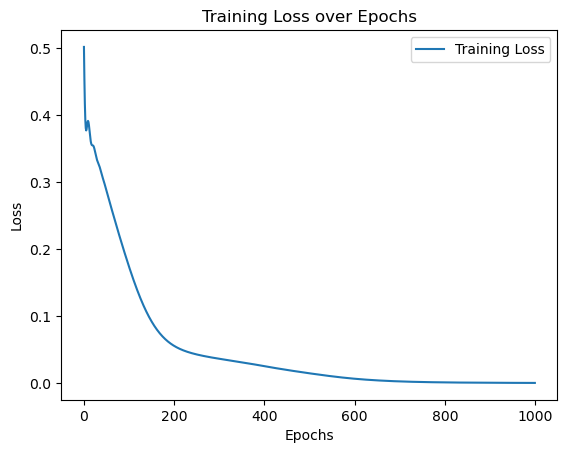

Accuracy of the model: 100.00%


In [6]:
val_data = TensorDataset(X_tensor, Y_tensor)
val_loader = DataLoader(val_data, batch_size=1, shuffle=False)

model = MLP_sigmoid(dict['input_size'], dict['hidden_size'], dict['output_size'], None)
training_losses = model.train_network(dict['lr'], dict['epochs'], X_tensor, Y_tensor,early_stopping=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

model.plot_training_loss(training_losses)

model.validate(val_loader, device)

In [7]:
set=["2024_12_22_at_14_34_act_[0,2,0.1,-4,4,800,12]_train_[1,10,1,15,0.01,20]_gen_[1500,50,12,Crossover_prof,2,10,Flip_Bit_Mutation,2,2].pkl",
     "2024_12_22_at_16_40_act_[0,1,0.2,-4,4,800,6]_train_[1,12,1,15,0.01,20]_gen_[1500,50,12,Crossover_prof,2,10,Flip_Bit_Mutation,2,2].pkl",
     "2024_12_22_at_19_06_act_[0,1.4,0.1,-4,4,800,8]_train_[1,12,1,15,0.01,20]_gen_[1500,50,12,Crossover_prof,2,10,Flip_Bit_Mutation,2,2].pkl",
     "2024_12_22_at_15_24_act_[0,1,0.1,-4,4,800,8]_train_[1,12,1,15,0.01,20]_gen_[1500,50,12,Crossover_prof,2,10,Flip_Bit_Mutation,2,2].pkl"]

In [8]:
string_file = "Results/2024_12_22_at_15_24_act_[0,1,0.1,-4,4,800,8]_train_[1,12,1,15,0.01,20]_gen_[1500,50,12,Crossover_prof,2,10,Flip_Bit_Mutation,2,2].pkl"

net_data, pars = load_data(string_file)
best_net=min(net_data[-1], key=lambda x: x.score)
best_gen = best_net.genome

#best_last_gen_genome = [0.0, 2.1, 1.2, 0.6, 0.6, 0.6, 1.2, 2.1, 2.4, 2.4, 2.4, 1.5, 1.8, 2.1, 0.0, 0.9, 1.2, 0.6, 0.3, 0.6, 1.5,2.1, 2.7, 2.4, 2.4, 1.8, 2.1, 2.7]

net_test = Individual(best_gen,dict['input_size'],dict['hidden_size'], dict['output_size'])
net_test.training(dict['lr'], dict['epochs'], X_tensor, Y_tensor, patience=10, early_stopping=False)

Epoch 1/1000, Training Loss: 2.0042
Epoch 2/1000, Training Loss: 1.8059
Epoch 3/1000, Training Loss: 1.6199
Epoch 4/1000, Training Loss: 1.4463
Epoch 5/1000, Training Loss: 1.2852
Epoch 6/1000, Training Loss: 1.1369
Epoch 7/1000, Training Loss: 1.0012
Epoch 8/1000, Training Loss: 0.8782
Epoch 9/1000, Training Loss: 0.7677
Epoch 10/1000, Training Loss: 0.6694
Epoch 11/1000, Training Loss: 0.5832
Epoch 12/1000, Training Loss: 0.5086
Epoch 13/1000, Training Loss: 0.4451
Epoch 14/1000, Training Loss: 0.3921
Epoch 15/1000, Training Loss: 0.3490
Epoch 16/1000, Training Loss: 0.3149
Epoch 17/1000, Training Loss: 0.2890
Epoch 18/1000, Training Loss: 0.2703
Epoch 19/1000, Training Loss: 0.2580
Epoch 20/1000, Training Loss: 0.2510
Epoch 21/1000, Training Loss: 0.2483
Epoch 22/1000, Training Loss: 0.2490
Epoch 23/1000, Training Loss: 0.2521
Epoch 24/1000, Training Loss: 0.2568
Epoch 25/1000, Training Loss: 0.2623
Epoch 26/1000, Training Loss: 0.2680
Epoch 27/1000, Training Loss: 0.2733
Epoch 28/1

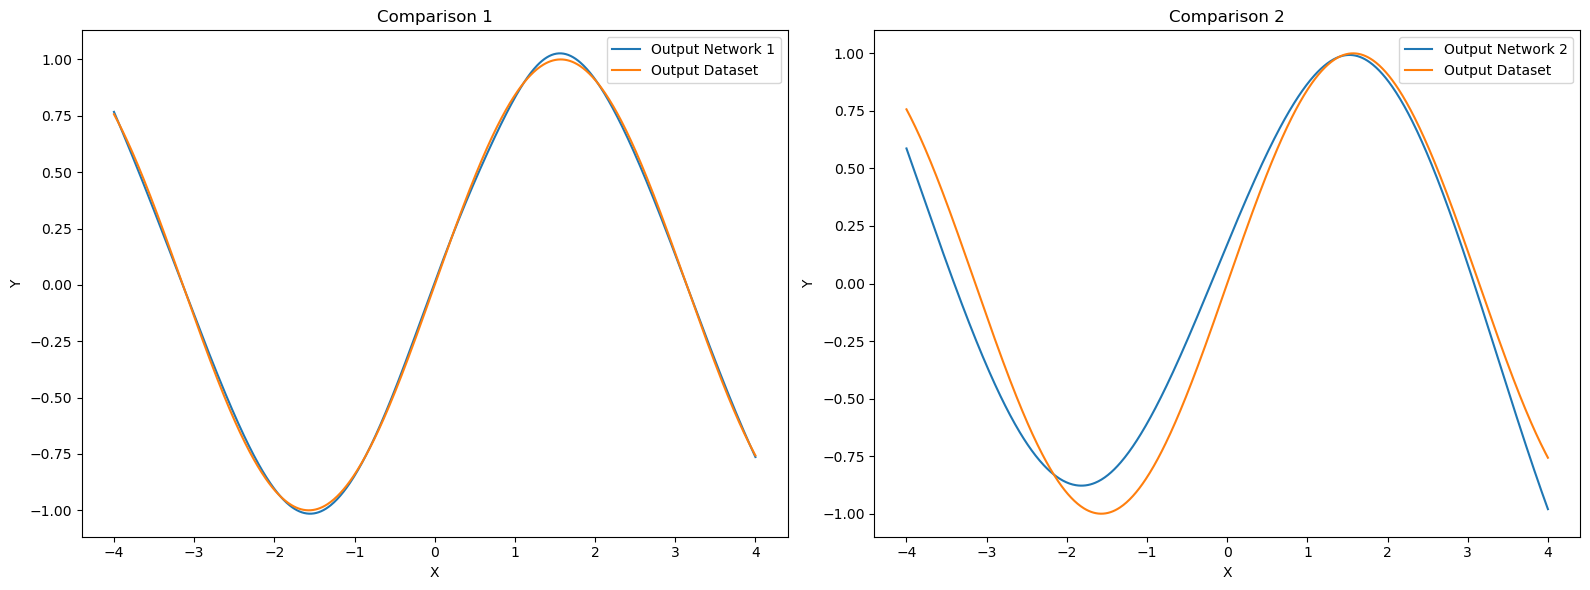

In [9]:
plt.figure(figsize=(16, 6))  

plt.subplot(1, 4, (1, 2))
plt.plot(X_tensor, model(X_tensor).detach().numpy(), label="Output Network 1")
plt.plot(X_tensor, Y_tensor, label="Output Dataset")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Comparison 1")
plt.legend()

plt.subplot(1, 4, (3, 4))
plt.plot(X_tensor, net_test.network(X_tensor).detach().numpy(), label="Output Network 2")
plt.plot(X_tensor, Y_tensor, label="Output Dataset")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Comparison 2")
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
net_test.validate(val_loader, device)

Accuracy of the model: 30.25%


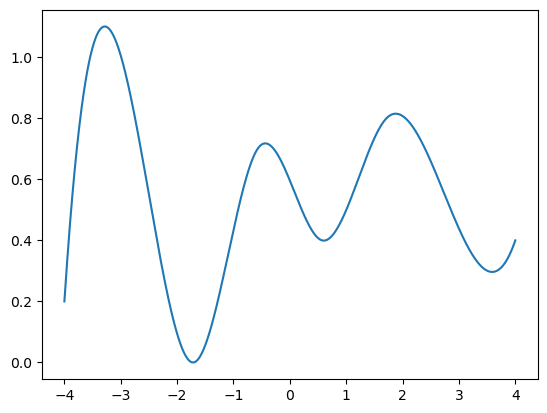

In [11]:
net_act_test = act_func_generator(best_net.genome, pars['lim_inf'], pars['lim_sup'])
x_doms = np.linspace(pars['lim_inf'], pars['lim_sup'], pars['step_domain'])
y_doms = net_act_test(x_doms)
plt.plot(x_doms, y_doms)

In [12]:
# final_loss_mlp_sigmoid = training_losses[-1]  # Ultima perdita della rete MLP sigmoide


In [13]:
# # Curva di perdita per la MLP Custom
# plt.plot(Mean_sim, label="Algoritmo Genetico (MSE)")
# 
# # Curva di perdita per la MLP Sigmoide
# plt.plot(training_losses, label="MLP Sigmoide (MSE)")
# 
# plt.xlabel("Epoche")
# plt.ylabel("Perdita (Loss)")
# plt.title("Confronto tra Algoritmo Genetico e MLP Sigmoide")
# plt.legend()
# plt.show()
# 
# print(f"Perdita finale MLP Custom (Algoritmo Genetico): {best_individual_loss}")
# print(f"Perdita finale MLP Sigmoide: {final_loss_mlp_sigmoid}")
